# All-sky analysis plots for the paper

In this notebook, you find all the plots used in the paper about visible channel.
test

## Import libraries and data

In [1]:
import sys

sys.path.append("/perm/km4c/RTTOV_AROME")
sys.path.append("/etc/ecmwf/nfs/dh2_home_b/km4c/.local/lib/python3.8/site-packages")
sys.path.append("/perm/km4c/RTTOV_AROME/read_output_data")
sys.path.append("/perm/km4c/RTTOV_AROME/plot_results")

from results_vis_all_sky_a1 import *
from utils1 import *
from utils2 import *

# Used to mask data points beyond the AROME model domain
domain_mask = np.load("/perm/km4c/RTTOV_AROME/masks/AROME_Mask.npy")

/etc/ecmwf/nfs/dh2_perm_b/kipg/venvs/venv_38/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.2' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/etc/ecmwf/nfs/dh2_perm_b/kipg/venvs/venv_38/lib/python3.8/site-packages/xarray/backends/plugins.py:71: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/etc/ecmwf/nfs/dh2_perm_b/kipg/venvs/venv_38/lib/python3.8/site-packages/xarray/backends/plugins.py:71: RuntimeWarning: Engine 'rasterio' loading failed:
libgdal.so.28: cannot open shared object file: No such file or directory
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


FileNotFoundError: [Errno 2] No such file or directory: b'/etc/ecmwf/scratch/km4c/ml_simulations/visible/Results_tmp_all_datetimes/rttov_v122_v3.1.nc'

In [3]:
# Read the Elevation height
import pygrib
sys.path.append("/perm/km4c/RTTOV_AROME/run_rttov")
from visir_profiles_arome import *
from visir_obs_utils import map_to_sat_grid_edited
grbs = []
grb_path = f"/etc/ecmwf/hpcperm/km4c/arome_forecasts/august23/day_01/20230801_12_0003.grb"
tmp = pygrib.open(grb_path)
grbs.append(tmp)
z_surface = get_profile(grbs, 0, 8, "surface", plot_par = False)
terrain, _ = map_to_sat_grid_edited(z_surface.data[0,:,:], channel='', varname='refl', plot_only_latlon=False, 
                                    vmin=None, vmax=None, cmap=None, save_tile=False, dbg=False, repo_path='/perm/km4c/')
H = (terrain*domain_mask)/1000

latlon2xy constants  0.731991592560469 1.836504601854703 1.0103403109190163
misses in latlon2tri_exact_exec:  57644


NameError: name 'domain_mask' is not defined

## Maps

In [ ]:
hour = '120000'
out_1 = exp_results['default']["O"]["20230805_120000"]
out_2 = exp_results['default']["B-rttov12"]["20230805_120000"]
out_3 = exp_results['default']["B-rttov13"]["20230805_120000"]

geo_map_vis([out_1, out_2, out_3], ["O", "B (v12)", "B (v13)"], cmaps=["cubehelix", "cubehelix", "cubehelix"],
            date="", unit="R []",
            lon=rttov122["default"].data.lon_obs_map.values, 
            lat=rttov122["default"].data.lat_obs_map.values,
            vmin=0, vmax=1,save=False,shrink=0.2,
            out_path='/home/km4c/to_ucloud/',
            name='R_all_sky_20230805_120000'
            )

## Histograms

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

bins = 100
range_ = (0, 1.0)
log_scale = False

fig, axs = plt.subplots(1, 2, figsize=(10, 6))
plt.rcParams.update({"font.size":14})
fig.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95, wspace=0.0, hspace=0.0)

axs = axs.flatten()  # makes indexing easier

# first plot
axs[0].hist(flatten_array(ref["O"]), bins=100, 
              log=log_scale,histtype='step', color = 'black',range= range_, lw=2, label = 'O');
axs[0].hist(flatten_array(ref["B-rttov12"]), bins=100, 
              log=log_scale,histtype='step', color = '#3ba3ec',range= range_, lw=2, label = 'B (v12)');
axs[0].hist(flatten_array(ref["B-rttov13"]), bins=100, 
              log=log_scale,histtype='step', color = '#f564d4',range= range_, lw=2, label = 'B (v13)');
axs[0].set_title("", fontsize=14)
axs[0].set_xlabel("R []", fontsize=14)
axs[0].set_xlim(0,1)
axs[0].set_ylabel("Counts", fontsize=14)
axs[0].legend(fontsize=14)

bins = 100
range_ = (-0.5, 0.5)
log_scale = False

# second plot
axs[1].hist(flatten_array(ref["OmB-12"]), bins=100, 
              log=log_scale,histtype='step', color = '#3ba3ec',range= range_, lw=2, label = 'OmB (v12)');
axs[1].hist(flatten_array(ref["OmB-13"]), bins=100, 
              log=log_scale,histtype='step', color = '#f564d4',range= range_, lw=2, label = 'OmB (v13)');
axs[1].set_title("", fontsize=14)
axs[1].set_xlabel("ΔR []", fontsize=14)
axs[1].yaxis.set_visible(False)
axs[1].set_xlim(-0.5, 0.5)
axs[1].legend(fontsize=14)

plt.tight_layout()
# plt.savefig("/home/km4c/to_ucloud/R_hist_all_sky_12utc.png", dpi=300)
plt.show()

## Sensitivity to spatial resolution

### Point spread function (PSF)

The option is only available with the visop operator

In [6]:
L_visop = lambda X, Y, d1=M1, d2=M: (
    X.data
     .synthetic_reflectance_VIS006
     .sel(datetimes=Y)
     .values
    * d1 * d2
)
O = lambda X, Y, d1=M1, d2=M: (
    X.data
     .observed_reflectance_VIS006
     .sel(datetimes=Y)
     .values
    * d1* d2
)

In [7]:
datetime_slice = list(f"202308{x:02d}_{hours[2]}" for x in range(1,32))
sims_psf = pd.DataFrame()
sims_psf["O"] = flatten_array(O(visop['default'], datetime_slice))
sims_psf["B-psf=off"] = flatten_array(L_visop(visop['default'], datetime_slice))
sims_psf["B-psf=on"] = flatten_array(L_visop(visop['v2'], datetime_slice))

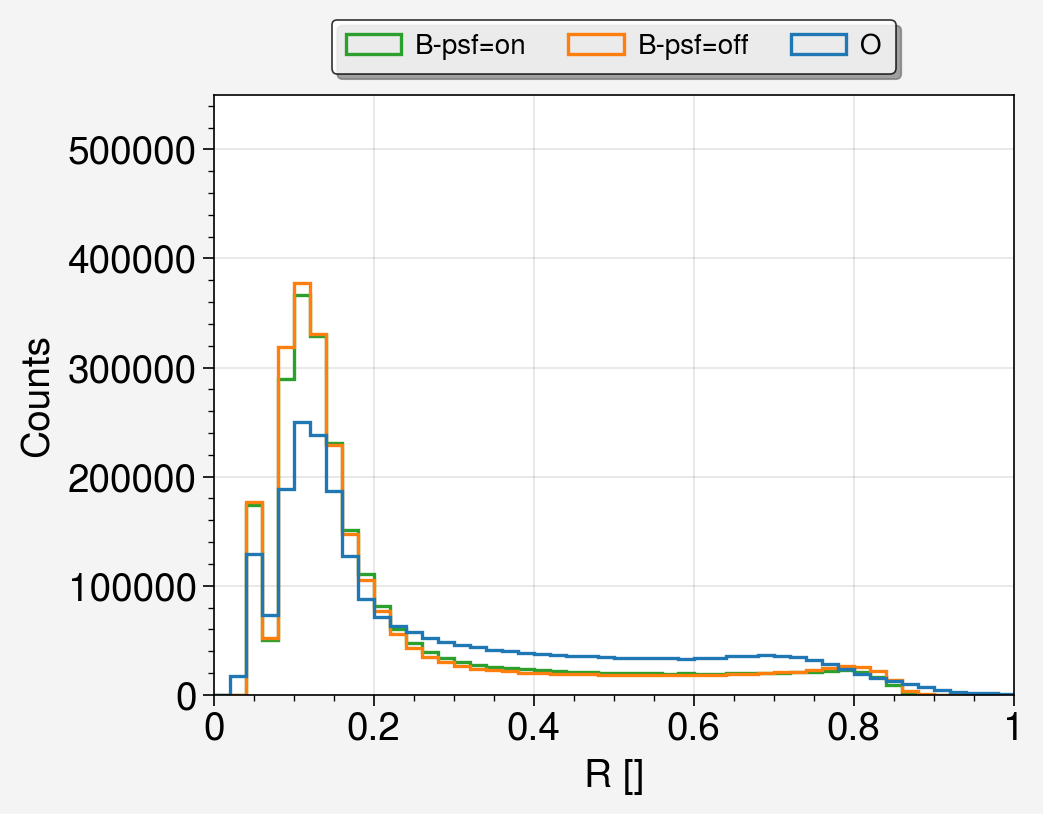

In [8]:
fig, ax = plot_simulations(sims_psf,x_lims=(0,1),y_lims=(0,550000),
                     bins=50,
                     range_=(0,1),
                     colors=None,
                     alpha=1,
                     legend_loc='c',
                     title='',
                     xlabel='R []',
                     ylabel='Counts', log_x=False, log_y=False,save=False, name="/home/km4c/to_ucloud/psf_results")

### Superobbing - Philipp

Trying non-log scaling, and also not reading in the V12 data

In [5]:
superob = True
if superob:
    grid_sizes = {"S6": (2,1), "S12": (4,2), "S18":(6,3),"S36":(12,6)}
    # keys_to_process = ["O", "rttov12-default", "rttov13-default"]
    keys_to_process = ["O","rttov13-default"]
    exp_keys = {
        "O": "O",
        # "rttov12-default": "B-rttov12",
        "rttov13-default": "B-rttov13"
    }

    superobbed_results = {key: {size: {} for size in grid_sizes} for key in keys_to_process}
    flattened_results = {key: {size: None for size in grid_sizes} for key in keys_to_process}

    for date_time in datetime_slice:
        for key in keys_to_process:
            for size, window in grid_sizes.items():
                # Perform superobbing
                input_data = exp_results['default'][exp_keys[key]][date_time]
                tmp_data = superobbing(input_data, window[0], window[1])
                superobbed_results[key][size][date_time] = tmp_data

    # Flatten all 2D arrays for all datetime slices into a single 1D array
    for key in keys_to_process:
        for size in grid_sizes:
            all_flattened = [
                superobbed_results[key][size][date_time].ravel()
                for date_time in datetime_slice
            ]
            flattened_results[key][size] = np.concatenate(all_flattened)

    if True: # distribution statistics
        data_list = []
        # Native resolution stats
        # for o, b12, b13 in zip(
        for o, b13 in zip(
            visop['default'].all_sky_observed,
            # rttov122['default'].all_sky_synthetic,
            rttov132['default'].all_sky_synthetic
        ):
            # data_list.append({"O": o, "OmB (v12)": o - b12 ,"B (v12)": b12, "B (v13)": b13, "OmB (v13)": o - b13, "size": "N-S"})
            data_list.append({"O": o,  "B (v13)": b13, "OmB (v13)": o - b13, "size": "N-S"})

        # Superobbed stats
        for size in grid_sizes:
            O_values = flattened_results["O"][size]
            # B12_values = flattened_results["rttov12-default"][size]
            B13_values = flattened_results["rttov13-default"][size]
            # OmB12_values = O_values - B12_values
            OmB13_values = O_values - B13_values

            # for o, omb12, b12, b13, omb13 in zip(O_values, OmB12_values, B12_values, B13_values, OmB13_values):
            for o, b13, omb13 in zip(O_values, B13_values, OmB13_values):
                data_list.append({"O": o, "B (v13)": b13, "OmB (v13)": omb13, "size": size})

        all_data = pd.DataFrame(data_list)
        all_data = all_data.dropna()

highest number in box =  1314449.0


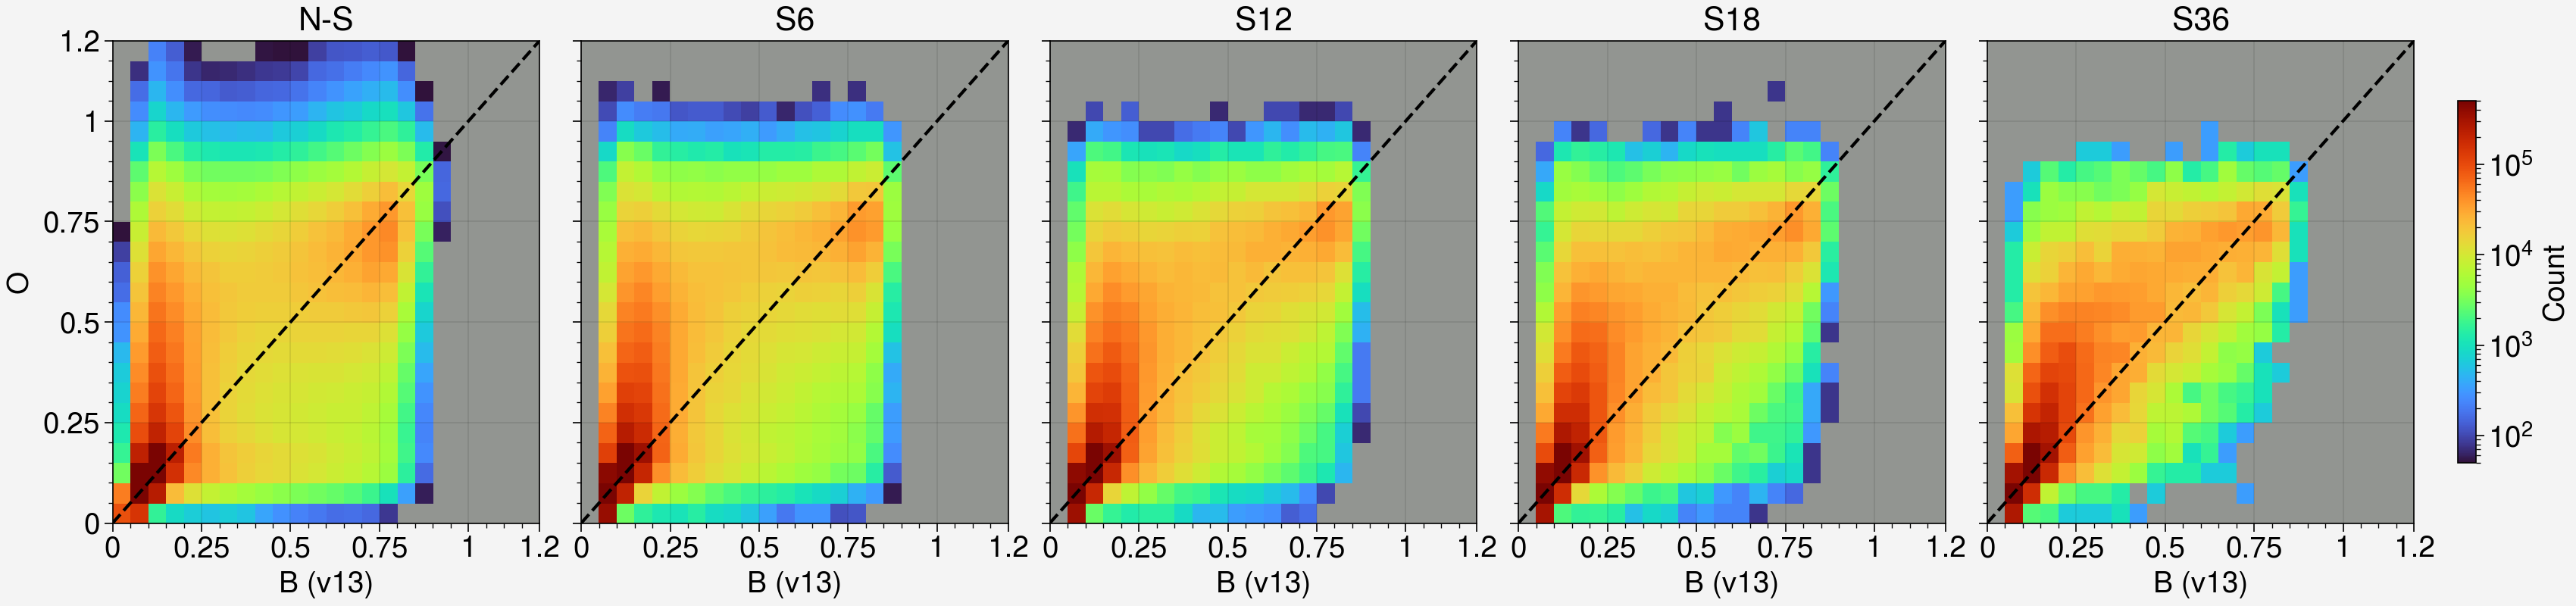

In [68]:
# Variables to plot, now trying a linear colormap
x_var = 'B (v13)'
y_var = 'O'
size_categories = ['N-S', 'S6', 'S12', 'S18', 'S36']

min_count = 50
max_count = 500000
# Log‐norm for your 2D histograms
norm = LogNorm(vmin=min_count, vmax=max_count)
cmap = sns.color_palette("PuBu", as_cmap=True)
cmap = sns.color_palette("inferno_r", as_cmap=True)
cmap = sns.color_palette("turbo", as_cmap=True)

# Make a 1×5 grid, one panel per size
fig, axes = plt.subplots(nrows=1, ncols=len(size_categories),
                         figsize=(17, 4), constrained_layout=True)
plt.rcParams.update({'font.size': 14})



for idx, size in enumerate(size_categories):
    ax = axes[idx]
    subset = all_data[all_data['size'] == size]
    x = subset[x_var]
    y = subset[y_var]

    if size =='N-S': ref_number_sample = len(x)

    # 2D‐histogram → masked array so zeros are transparent
    hist, xedges, yedges = np.histogram2d(x, y, bins=24,range=[[0,1.2],[0,1.2]])
    if size =='N-S': print('highest number in box = ',np.max(hist))
    # Normalize by number of samples
    hist_norm=hist*ref_number_sample/len(x)
    # hist_masked = np.ma.masked_where(hist ==0, hist)
    hist_masked = np.ma.masked_where(hist_norm <min_count, hist_norm)


    im = ax.imshow(
        hist_masked.T,
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap=cmap,
        norm=norm,
        # norm=norm,
        # vmax=100000,
        aspect='auto'
    )

    # y = x line
    ax.plot([0, 1.2], [0, 1.2], color='black', linestyle='--', linewidth=1.5)

    # axis limits
    major_ticks= [0, 0.25, 0.5, 0.75, 1,1.2]
    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    
    # labels & title
    ax.set_xlabel(x_var)
    if idx == 0:
        ax.set_ylabel(y_var)
    else:
        ax.tick_params(labelleft=False)
    ax.set_title(f"{size}")
    ax.set_facecolor('xkcd:grey')
# single colorbar on the right
fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    # plt.cm.ScalarMappable(cmap=cmap),
    ax=axes,
    location='right',
    shrink=0.75,pad=0.01,
    label=f'Count'
)
plt.savefig("./20250722_2dhist_log_min50_max500000_turbo.png", dpi=300)

# plt.savefig("/home/km4c/to_ucloud/hist_B_(v13)_vs_O.png", dpi=300)
plt.show()

highest number in box =  2215424.0


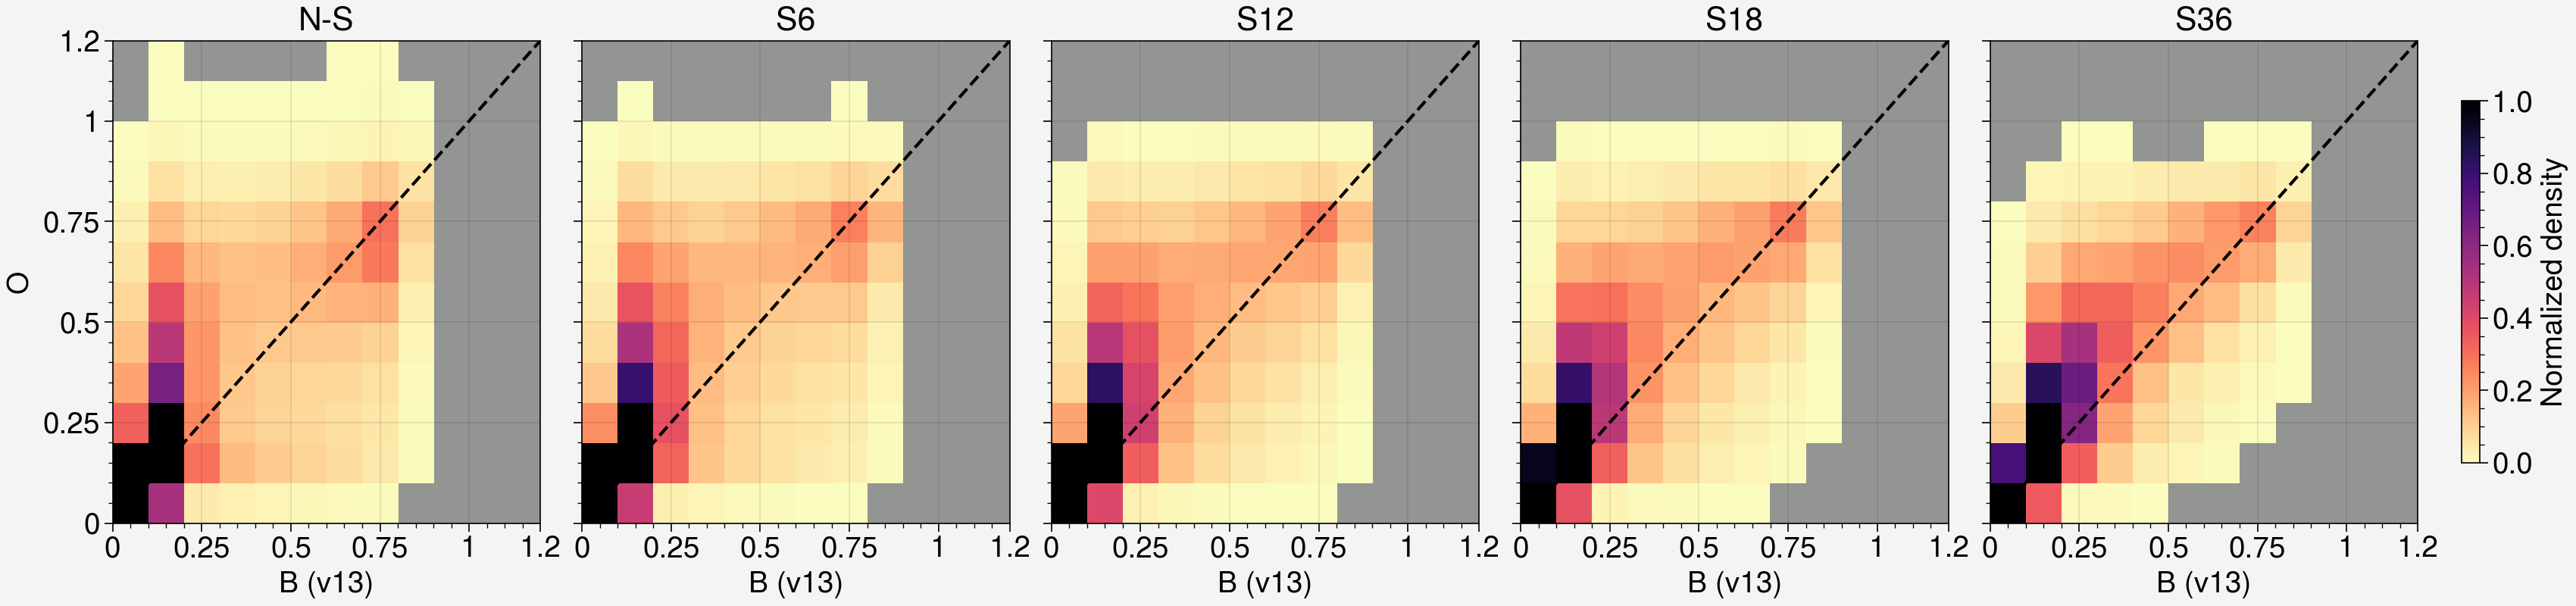

In [71]:
# Variables to plot, now trying a linear colormap
x_var = 'B (v13)'
y_var = 'O'
size_categories = ['N-S', 'S6', 'S12', 'S18', 'S36']

# Log‐norm for your 2D histograms
# norm = LogNorm(vmin=10, vmax=14000)
# norm = LogNorm(vmin=1000, vmax=1000000)
cmap = sns.color_palette("PuBu", as_cmap=True)
cmap = sns.color_palette("magma_r", as_cmap=True)

# Make a 1×5 grid, one panel per size
fig, axes = plt.subplots(nrows=1, ncols=len(size_categories),
                         figsize=(17, 4), constrained_layout=True)
plt.rcParams.update({'font.size': 14})



for idx, size in enumerate(size_categories):
    ax = axes[idx]
    subset = all_data[all_data['size'] == size]
    x = subset[x_var]
    y = subset[y_var]

    if size =='N-S': ref_number_sample = len(x)

    # 2D‐histogram → masked array so zeros are transparent
    hist, xedges, yedges = np.histogram2d(x, y, bins=12,range=[[0,1.2],[0,1.2]])
    if size =='N-S': print('highest number in box = ',np.max(hist))
    # Normalize by number of samples
    hist_norm=hist*ref_number_sample/len(x)
    # hist_masked = np.ma.masked_where(hist ==0, hist)
    hist_masked = np.ma.masked_where(hist_norm <500, hist_norm)


    im = ax.imshow(
        hist_masked.T,
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap=cmap,
        # norm=norm,
        # norm=norm,
        vmax=500000,
        aspect='auto'
    )

    # y = x line
    ax.plot([0, 1.2], [0, 1.2], color='black', linestyle='--', linewidth=1.5)

    # axis limits
    major_ticks= [0, 0.25, 0.5, 0.75, 1,1.2]
    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    
    # labels & title
    ax.set_xlabel(x_var)
    if idx == 0:
        ax.set_ylabel(y_var)
    else:
        ax.tick_params(labelleft=False)
    ax.set_title(f"{size}")
    ax.set_facecolor('xkcd:grey')
# single colorbar on the right
fig.colorbar(
    # plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    plt.cm.ScalarMappable(cmap=cmap),
    ax=axes,
    location='right',
    shrink=0.75,pad=0.01,
    label=f'Normalized density'
)

plt.savefig("./20250722_2dhist_lin_min500_max500000_magma.png", dpi=300)
plt.show()

highest number in box =  1314449.0


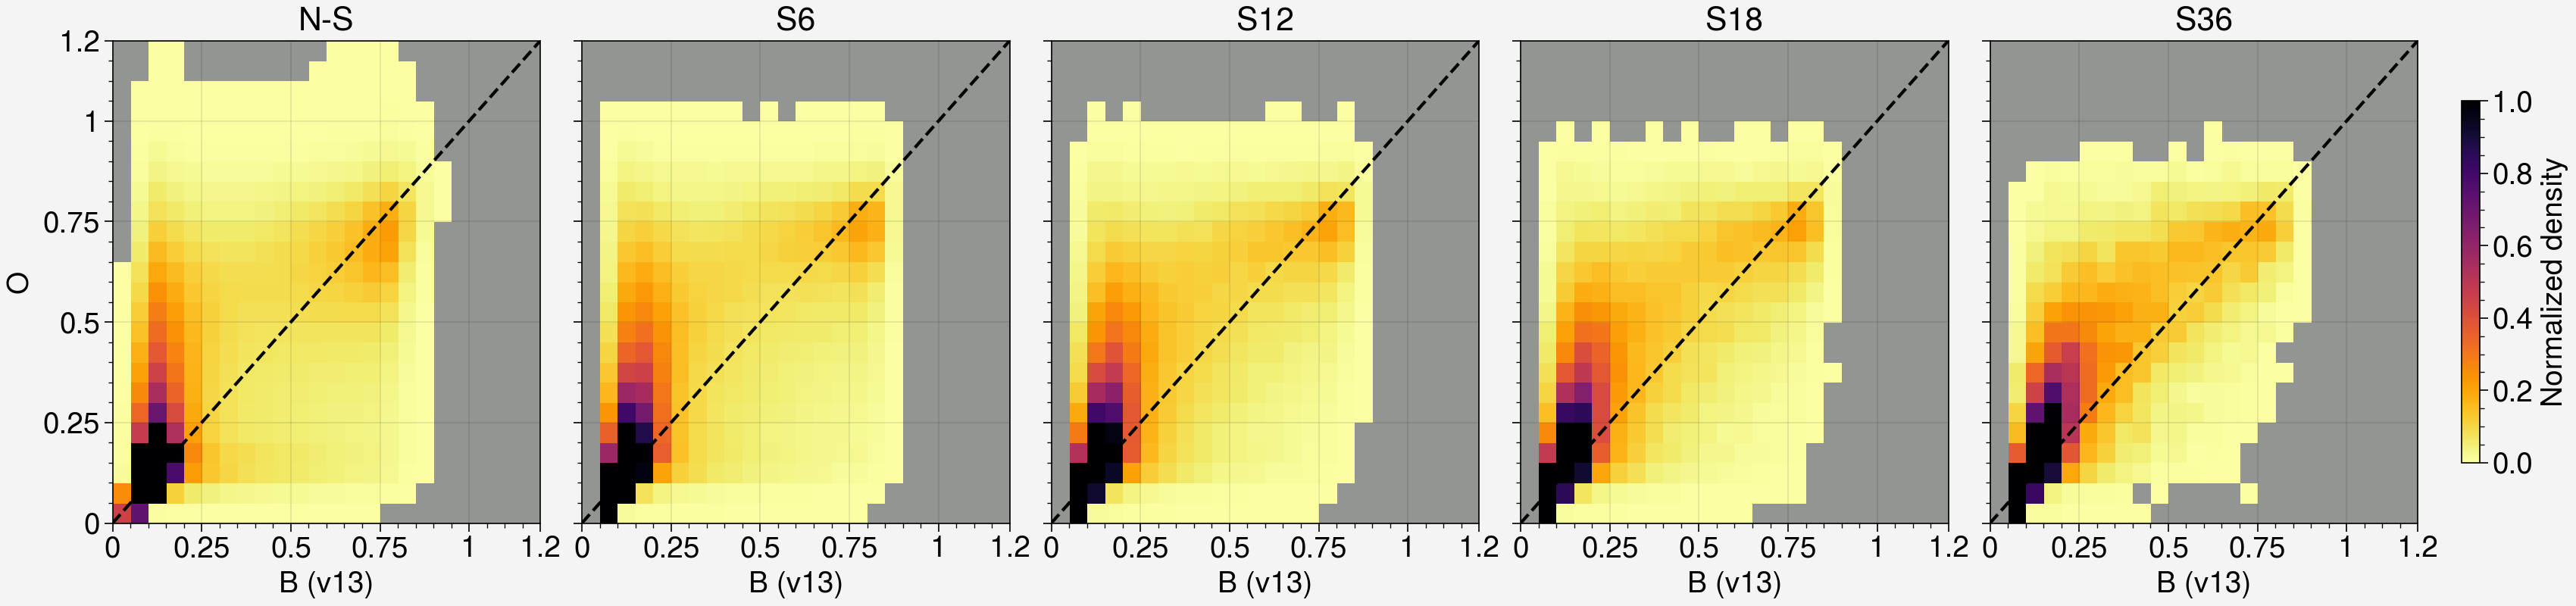

In [74]:
# Variables to plot, now trying a linear colormap
x_var = 'B (v13)'
y_var = 'O'
size_categories = ['N-S', 'S6', 'S12', 'S18', 'S36']

# Log‐norm for your 2D histograms
# norm = LogNorm(vmin=10, vmax=14000)
# norm = LogNorm(vmin=1000, vmax=1000000)
cmap = sns.color_palette("PuBu", as_cmap=True)
cmap = sns.color_palette("inferno_r", as_cmap=True)

# Make a 1×5 grid, one panel per size
fig, axes = plt.subplots(nrows=1, ncols=len(size_categories),
                         figsize=(17, 4), constrained_layout=True)
plt.rcParams.update({'font.size': 14})



for idx, size in enumerate(size_categories):
    ax = axes[idx]
    subset = all_data[all_data['size'] == size]
    x = subset[x_var]
    y = subset[y_var]

    if size =='N-S': ref_number_sample = len(x)

    # 2D‐histogram → masked array so zeros are transparent
    hist, xedges, yedges = np.histogram2d(x, y, bins=24,range=[[0,1.2],[0,1.2]])
    if size =='N-S': print('highest number in box = ',np.max(hist))
    # Normalize by number of samples
    hist_norm=hist*ref_number_sample/len(x)
    # hist_masked = np.ma.masked_where(hist ==0, hist)
    hist_masked = np.ma.masked_where(hist_norm <100, hist_norm)


    im = ax.imshow(
        hist_masked.T,
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap=cmap,
        # norm=norm,
        # norm=norm,
        vmax=200000,
        aspect='auto'
    )

    # y = x line
    ax.plot([0, 1.2], [0, 1.2], color='black', linestyle='--', linewidth=1.5)

    # axis limits
    major_ticks= [0, 0.25, 0.5, 0.75, 1,1.2]
    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    
    # labels & title
    ax.set_xlabel(x_var)
    if idx == 0:
        ax.set_ylabel(y_var)
    else:
        ax.tick_params(labelleft=False)
    ax.set_title(f"{size}")
    ax.set_facecolor('xkcd:grey')
# single colorbar on the right
fig.colorbar(
    # plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    plt.cm.ScalarMappable(cmap=cmap),
    ax=axes,
    location='right',
    shrink=0.75,pad=0.01,
    label=f'Normalized density'
)
plt.savefig("./20250722_2dhist_lin_min100_max200000_inferno.png", dpi=300)

plt.show()

In [44]:
ref_number_sample

10211772

In [ ]:
superob = True
if superob:
    grid_sizes = {"S6": (2,1), "S12": (4,2), "S18":(6,3),"S36":(12,6)}
    keys_to_process = ["O", "rttov12-default", "rttov13-default"]
    exp_keys = {
        "O": "O",
        "rttov12-default": "B-rttov12",
        "rttov13-default": "B-rttov13"
    }

    superobbed_results = {key: {size: {} for size in grid_sizes} for key in keys_to_process}
    flattened_results = {key: {size: None for size in grid_sizes} for key in keys_to_process}

    for date_time in datetime_slice:
        for key in keys_to_process:
            for size, window in grid_sizes.items():
                # Perform superobbing
                input_data = exp_results['default'][exp_keys[key]][date_time]
                tmp_data = superobbing(input_data, window[0], window[1])
                superobbed_results[key][size][date_time] = tmp_data

    # Flatten all 2D arrays for all datetime slices into a single 1D array
    for key in keys_to_process:
        for size in grid_sizes:
            all_flattened = [
                superobbed_results[key][size][date_time].ravel()
                for date_time in datetime_slice
            ]
            flattened_results[key][size] = np.concatenate(all_flattened)

    if True: # distribution statistics
        data_list = []
        # Native resolution stats
        for o, b12, b13 in zip(
            visop['default'].all_sky_observed,
            rttov122['default'].all_sky_synthetic,
            rttov132['default'].all_sky_synthetic
        ):
            data_list.append({"O": o, "OmB (v12)": o - b12 ,"B (v12)": b12, "B (v13)": b13, "OmB (v13)": o - b13, "size": "N-S"})

        # Superobbed stats
        for size in grid_sizes:
            O_values = flattened_results["O"][size]
            B12_values = flattened_results["rttov12-default"][size]
            B13_values = flattened_results["rttov13-default"][size]
            OmB12_values = O_values - B12_values
            OmB13_values = O_values - B13_values

            for o, omb12, b12, b13, omb13 in zip(O_values, OmB12_values, B12_values, B13_values, OmB13_values):
                data_list.append({"O": o, "OmB (v12)": omb12, "B (v12)": b12, "B (v13)": b13, "OmB (v13)": omb13, "size": size})

        all_data = pd.DataFrame(data_list)
        all_data = all_data.dropna()

In [ ]:
# Variables to plot
x_var = 'B (v13)'
y_var = 'O'
size_categories = ['N-S', 'S6', 'S12', 'S18', 'S36']

# Log‐norm for your 2D histograms
norm = LogNorm(vmin=10, vmax=14000)
cmap = sns.color_palette("PuBu", as_cmap=True)

# Make a 1×5 grid, one panel per size
fig, axes = plt.subplots(nrows=1, ncols=len(size_categories),
                         figsize=(17, 4), constrained_layout=True)
plt.rcParams.update({'font.size': 14})
for idx, size in enumerate(size_categories):
    ax = axes[idx]
    subset = all_data[all_data['size'] == size]
    x = subset[x_var]
    y = subset[y_var]

    # 2D‐histogram → masked array so zeros are transparent
    hist, xedges, yedges = np.histogram2d(x, y, bins=50)
    hist_masked = np.ma.masked_where(hist == 0, hist)

    im = ax.imshow(
        hist_masked.T,
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap=cmap,
        norm=norm,
        aspect='auto'
    )

    # y = x line
    ax.plot([0, 1.2], [0, 1.2], color='black', linestyle='--', linewidth=1.5)

    # axis limits
    major_ticks= [0, 0.25, 0.5, 0.75, 1,1.2]
    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    
    # labels & title
    ax.set_xlabel(x_var)
    if idx == 0:
        ax.set_ylabel(y_var)
    else:
        ax.tick_params(labelleft=False)
    ax.set_title(f"{size}")
    ax.set_facecolor('xkcd:grey')
# single colorbar on the right
fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    location='right',
    shrink=0.75,pad=0.01,
    label=f'Count (log scale)'
)

# plt.savefig("/home/km4c/to_ucloud/hist_B_(v13)_vs_O.png", dpi=300)
plt.show()

## Sensitivity to snow

In [17]:
L = lambda X, Y, d1=M1, d2=M: (
    X.data
     .synthetic_reflectance_VIS006
     .sel(datetimes=Y, sky_condition='all_sky')
     .values
    * d1 * d2
)
O = lambda X, Y, d1=M1, d2=M: (
    X.data
     .observed_reflectance_VIS006
     .sel(datetimes=Y)
     .values
    * d1* d2
)

In [18]:
datetime_slice = list(f"202308{x:02d}_{hours[2]}" for x in range(1,32))
sims_snow = pd.DataFrame()
sims_snow["O"] = flatten_array(O(visop['default'], datetime_slice))
sims_snow["B-12-default"] = flatten_array(L(rttov122['default'], datetime_slice))
sims_snow["B-12-10%"] = flatten_array(L(rttov122['v1'], datetime_slice)) 
sims_snow["B-12-20%"] = flatten_array(L(rttov122['v1.1'], datetime_slice))
sims_snow["B-12-100%"] = flatten_array(L(rttov122['v1.2'], datetime_slice))
sims_snow["B-13-default"] = flatten_array(L(rttov132['default'], datetime_slice))
sims_snow["B-13-10%"] = flatten_array(L(rttov132['v1'], datetime_slice))
sims_snow["B-13-100%"] = flatten_array(L(rttov132['v1.2'], datetime_slice))

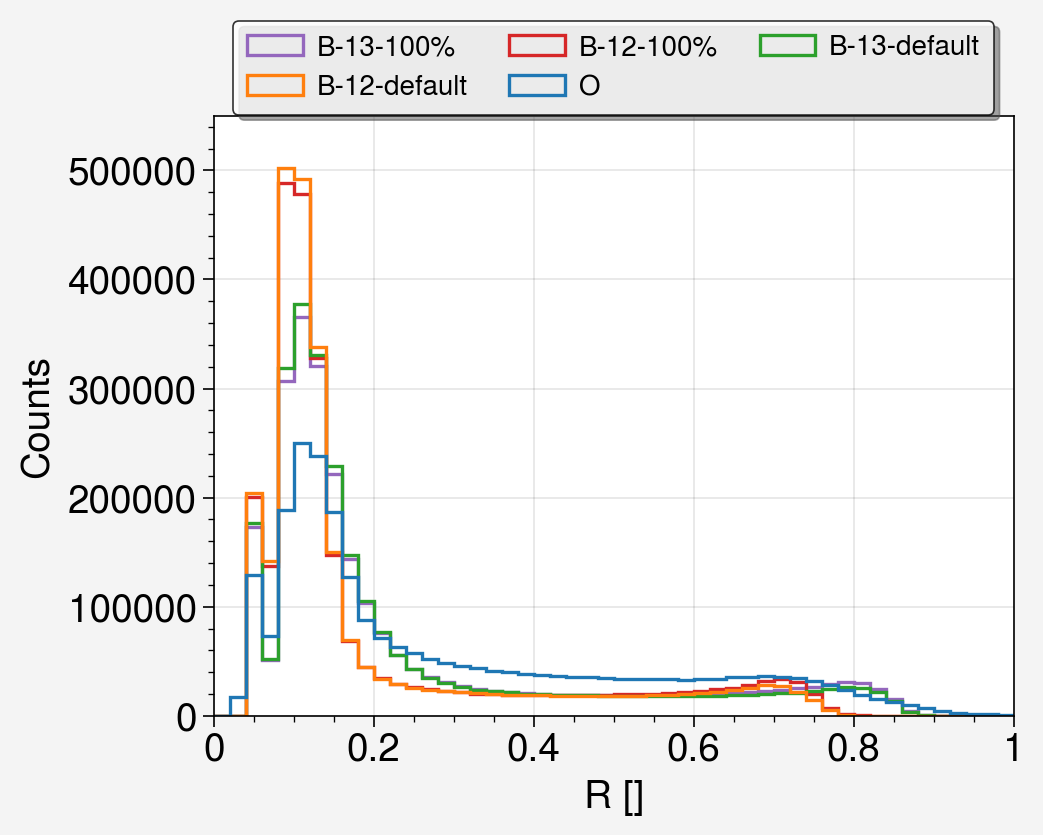

In [19]:
fig, ax = plot_simulations(sims_snow,columns=["O", "B-12-default","B-13-default", "B-12-100%", "B-13-100%"],x_lims=(0,1),y_lims=(0,550000),
                     bins=50,
                     range_=(0,1),
                     colors=None,
                     alpha=1,
                     legend_loc='c',
                     title='',
                     xlabel='R []',
                     ylabel='Counts', log_x=False, log_y=False,save=False, name="/home/km4c/to_ucloud/results_snow")

In [20]:
LON = rttov122["default"].data.lon_obs_map.values
LAT = rttov122["default"].data.lat_obs_map.values

date_time = "20230805_120000"
o = exp_results['default']["O"][date_time]
b13_0 = exp_results['default']["B-rttov13"][date_time]
b13_100 = exp_results['v1.2']["B-rttov13"][date_time]

In [21]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mtick

# # --- your existing slice and data prep ---
# r1, r2 = 80, 150
# c1, c2 = 240, 300
# x = LON[r1:r2, c1:c2]
# y = LAT[r1:r2, c1:c2]
# z_terrain = H[r1:r2, c1:c2] * 1000

# p1 = o[r1:r2, c1:c2]
# p2 = o[r1:r2, c1:c2] - b13_0[r1:r2, c1:c2]
# p3 = b13_100[r1:r2, c1:c2] - b13_0[r1:r2, c1:c2]

# # --- create a 1×3 figure ---
# fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)
# plt.rcParams.update({'font.size': 14})

# # common formatter for lon/lat
# for ax in axes:
#     ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
#     ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
#     ax.set_xlim(13, 15)
#     ax.set_ylim(46, 47)
#     ax.set_xlabel("°E")
# axes[0].set_ylabel("°N")

# # --- panel 1: O difference ---
# pcm1 = axes[0].pcolormesh(x, y, p1,
#                           vmin=0, vmax=1,
#                           cmap='cubehelix', shading='auto')
# cbar1 = fig.colorbar(pcm1, ax=axes[0], label="R []")
# cont1 = axes[0].contour(x, y, z_terrain,
#                        levels=5, cmap="copper", linewidths=1.8)
# axes[0].clabel(cont1, inline=True, fontsize=14, colors='black', fmt='%10.0f')

# axes[0].set_title("(a) O(12 UTC)")
# axes[0].set_facecolor('yellow')
# # --- panel 2: B difference ---
# pcm2 = axes[1].pcolormesh(x, y, p2,
#                           vmin=-0.5, vmax=0.5,
#                           cmap='RdBu_r', shading='auto')
# cbar2 = fig.colorbar(pcm2, ax=axes[1], label="ΔR []")
# cont2 = axes[1].contour(x, y, z_terrain,
#                        levels=5, cmap="copper",linewidths=1.8)
# axes[1].clabel(cont2, inline=True, fontsize=14, colors='black', fmt='%10.0f')

# axes[1].set_title("(b) OmB(12 UTC) with 0% snow")
# axes[1].set_facecolor('yellow')
# # --- panel 3: terrain ---
# pcm3 = axes[2].pcolormesh(x, y, p3,
#                           vmin=-0.5, vmax=0.5,
#                           cmap='RdBu_r', shading='auto')
# cbar3 = fig.colorbar(pcm3, ax=axes[2], label="ΔR []")
# cont3 = axes[2].contour(x, y, z_terrain,
#                        levels=5, colors="black", linewidths=1.8)
# axes[2].clabel(cont3, inline=True, fontsize=14, colors='black', fmt='%10.0f')

# axes[2].set_title("(c) B(100% snow) - B(0% snow)")
# axes[2].set_facecolor('yellow')
# # --- layout & save ---
# plt.tight_layout()
# plt.subplots_adjust(top=0.92)
# plt.savefig("/home/km4c/to_ucloud/snow_effects.png", dpi=1200)
# plt.show()

## Sensitivity to cloud condensation nuclei

In [24]:
L = lambda X, Y, d1=M1, d2=M: (
    X.data
     .synthetic_reflectance_VIS006
     .sel(datetimes=Y, sky_condition='all_sky')
     .values
    * d1 * d2
)
O = lambda X, Y, d1=M1, d2=M: (
    X.data
     .observed_reflectance_VIS006
     .sel(datetimes=Y)
     .values
    * d1* d2
)

In [25]:
#datetime_slice = "20230805_120000"
datetime_slice = list(f"202308{x:02d}_{hours[2]}" for x in range(1,32))
sims = pd.DataFrame()
sims["O"] = flatten_array(O(visop['default'], datetime_slice))
sims["B-12-default"] = flatten_array(L(rttov122['default'], datetime_slice))
sims["B-12-CCN_3.1"] = flatten_array(L(rttov122['v3.1'], datetime_slice)) 
sims["B-12-CCN_3.2"] = flatten_array(L(rttov122['v3.2'], datetime_slice))
sims["B-12-CCN_3.3"] = flatten_array(L(rttov122['v3.3'], datetime_slice))
sims["B-12-OPAC"] = flatten_array(L(rttov122['v4'], datetime_slice))
sims["B-13-default"] = flatten_array(L(rttov132['default'], datetime_slice))
sims["B-13-CCN_3.1"] = flatten_array(L(rttov132['v3.1'], datetime_slice)) 
sims["B-13-CCN_3.2"] = flatten_array(L(rttov132['v3.2'], datetime_slice))
sims["B-13-CCN_3.3"] = flatten_array(L(rttov132['v3.3'], datetime_slice))

In [27]:
L = (sims["B-13-CCN_3.3"]-sims["B-13-default"])*100/sims["B-13-default"]
print(f"min/max/mean {np.min(L)}/{np.max(L)}/{np.mean(L)}")
L = (sims["B-12-CCN_3.3"]-sims["B-12-default"])*100/sims["B-12-default"]
print(f"min/max/mean {np.min(L)}/{np.max(L)}/{np.mean(L)}")

min/max/mean 0.0/18.63665084718697/1.7926444523989216
min/max/mean 0.0/21.44198596313884/1.656998140441265


### Error statistics

In [29]:
# import numpy as np
# import pandas as pd

# # Sample data
# # Each column represents a distribution
# data = OmB
# data.columns.name = ''
# data.name = 'OmB'

# # Calculate error data
# # Passed to 'errdata' in the 3rd subplot example
# means = data.mean(axis=0)
# means.name = data.name  # copy name for formatting
# fadedata = np.percentile(data, (5, 95), axis=0)  # light shading
# shadedata = np.percentile(data, (25, 75), axis=0)  # dark shading

NameError: name 'OmB' is not defined

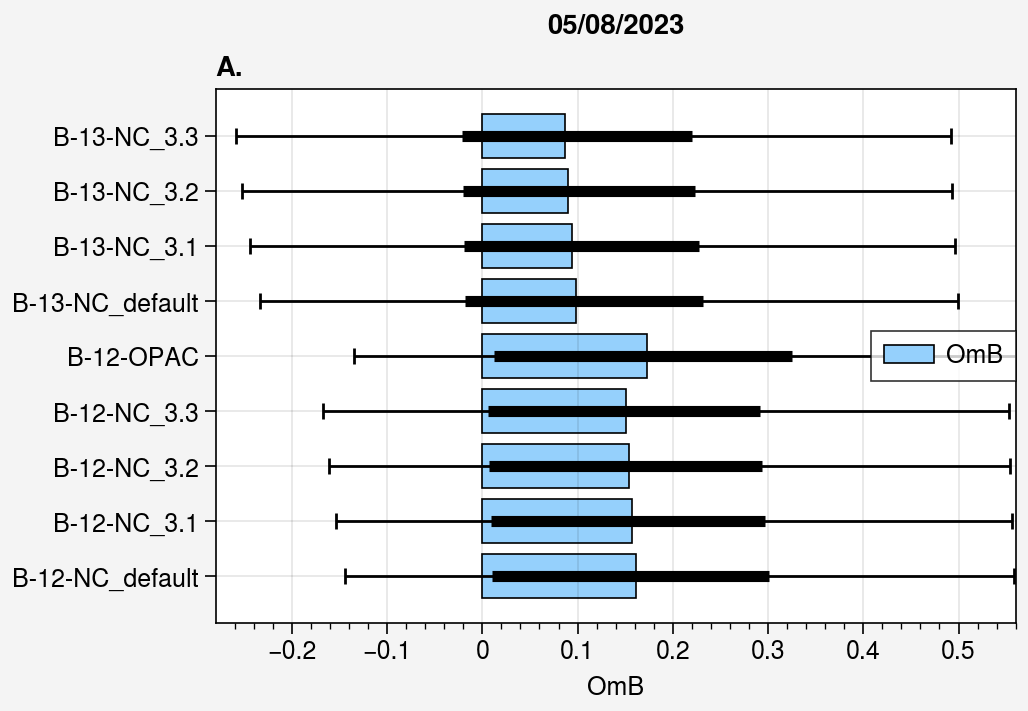

In [16]:
# import proplot as pplt
# import numpy as np

# # Loop through "vertical" and "horizontal" versions
# varray = [[1], [2], [3]]
# harray = [[1, 1]]
# orientation = 'horizontal'
# array = harray
# if True:
#     # Figure
#     fig = pplt.figure(refwidth=4, refaspect=1.5, share=False)
#     axs = fig.subplots(array)
#     axs.format(abc='A.', suptitle=f'05/08/2023') # 05/08/2023 Whole August

#     # Medians and percentile ranges
#     ax = axs[0]
#     kw = dict(
#         color='light blue', edgecolor='k', legend=True,
#         mean=True, barpctile=90, boxpctile=True,
#         # median=True, barpctile=(5, 95), boxpctile=(25, 75)  # equivalent
#     )
#     if orientation == 'horizontal':
#         ax.barh(data, **kw)
#     else:
#         ax.bar(data, **kw)
#     #ax.format(title='Bar plot')
#     ax.set_xlim(-0.28, 0.56)
#     fig.savefig("/home/km4c/to_ucloud/bar_plot_day.png", dpi=1200)

### Plotting histograms using proplot library

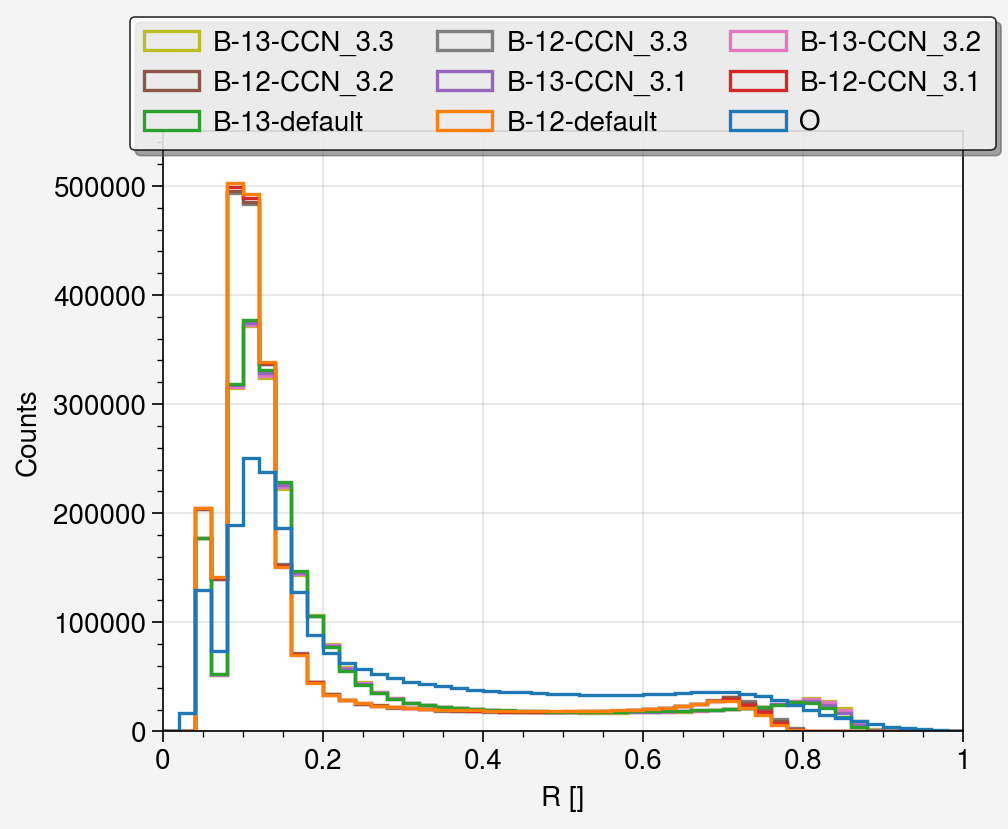

In [30]:
fig, ax = plot_simulations(sims,columns=['O',"B-12-default","B-13-default",'B-12-CCN_3.1','B-13-CCN_3.1',
                                         'B-12-CCN_3.2', 'B-13-CCN_3.2',
                                         'B-12-CCN_3.3', 'B-13-CCN_3.3'],x_lims=(0,1),y_lims=(0,550000),
                     bins=50,
                     range_=(0,1),
                     colors=None,
                     alpha=1,
                     legend_loc='c',
                     title='',
                     xlabel='R []',
                     ylabel='Counts', log_x=False, log_y=False,save=False, name="/home/km4c/to_ucloud/results_CCN")

## Map: Snow and CCN effects

In [31]:
LON = rttov122["default"].data.lon_obs_map.values
LAT = rttov122["default"].data.lat_obs_map.values

date_time = "20230803_120000"
o = exp_results['default']["O"][date_time]
b13_default = exp_results['default']["B-rttov13"][date_time]
b13_CCN3_3 = exp_results['v3.3']["B-rttov13"][date_time]

b13_100 = exp_results['v1.2']["B-rttov13"][date_time]

# --- your existing slice and data prep ---
r1, r2 = 80, 150
c1, c2 = 240, 300
x = LON[r1:r2, c1:c2]
y = LAT[r1:r2, c1:c2]
z_terrain = H[r1:r2, c1:c2] * 1000

p1 = o[r1:r2, c1:c2]
p2 = o[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]
p3 = b13_100[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]
p4 = b13_CCN3_3[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]

date_time = "20230805_120000"
o = exp_results['default']["O"][date_time]
b13_default = exp_results['default']["B-rttov13"][date_time]
b13_CCN3_3 = exp_results['v3.3']["B-rttov13"][date_time]

b13_100 = exp_results['v1.2']["B-rttov13"][date_time]

p5 = o[r1:r2, c1:c2]
p6 = o[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]
p7 = b13_100[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]
p8 = b13_CCN3_3[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]

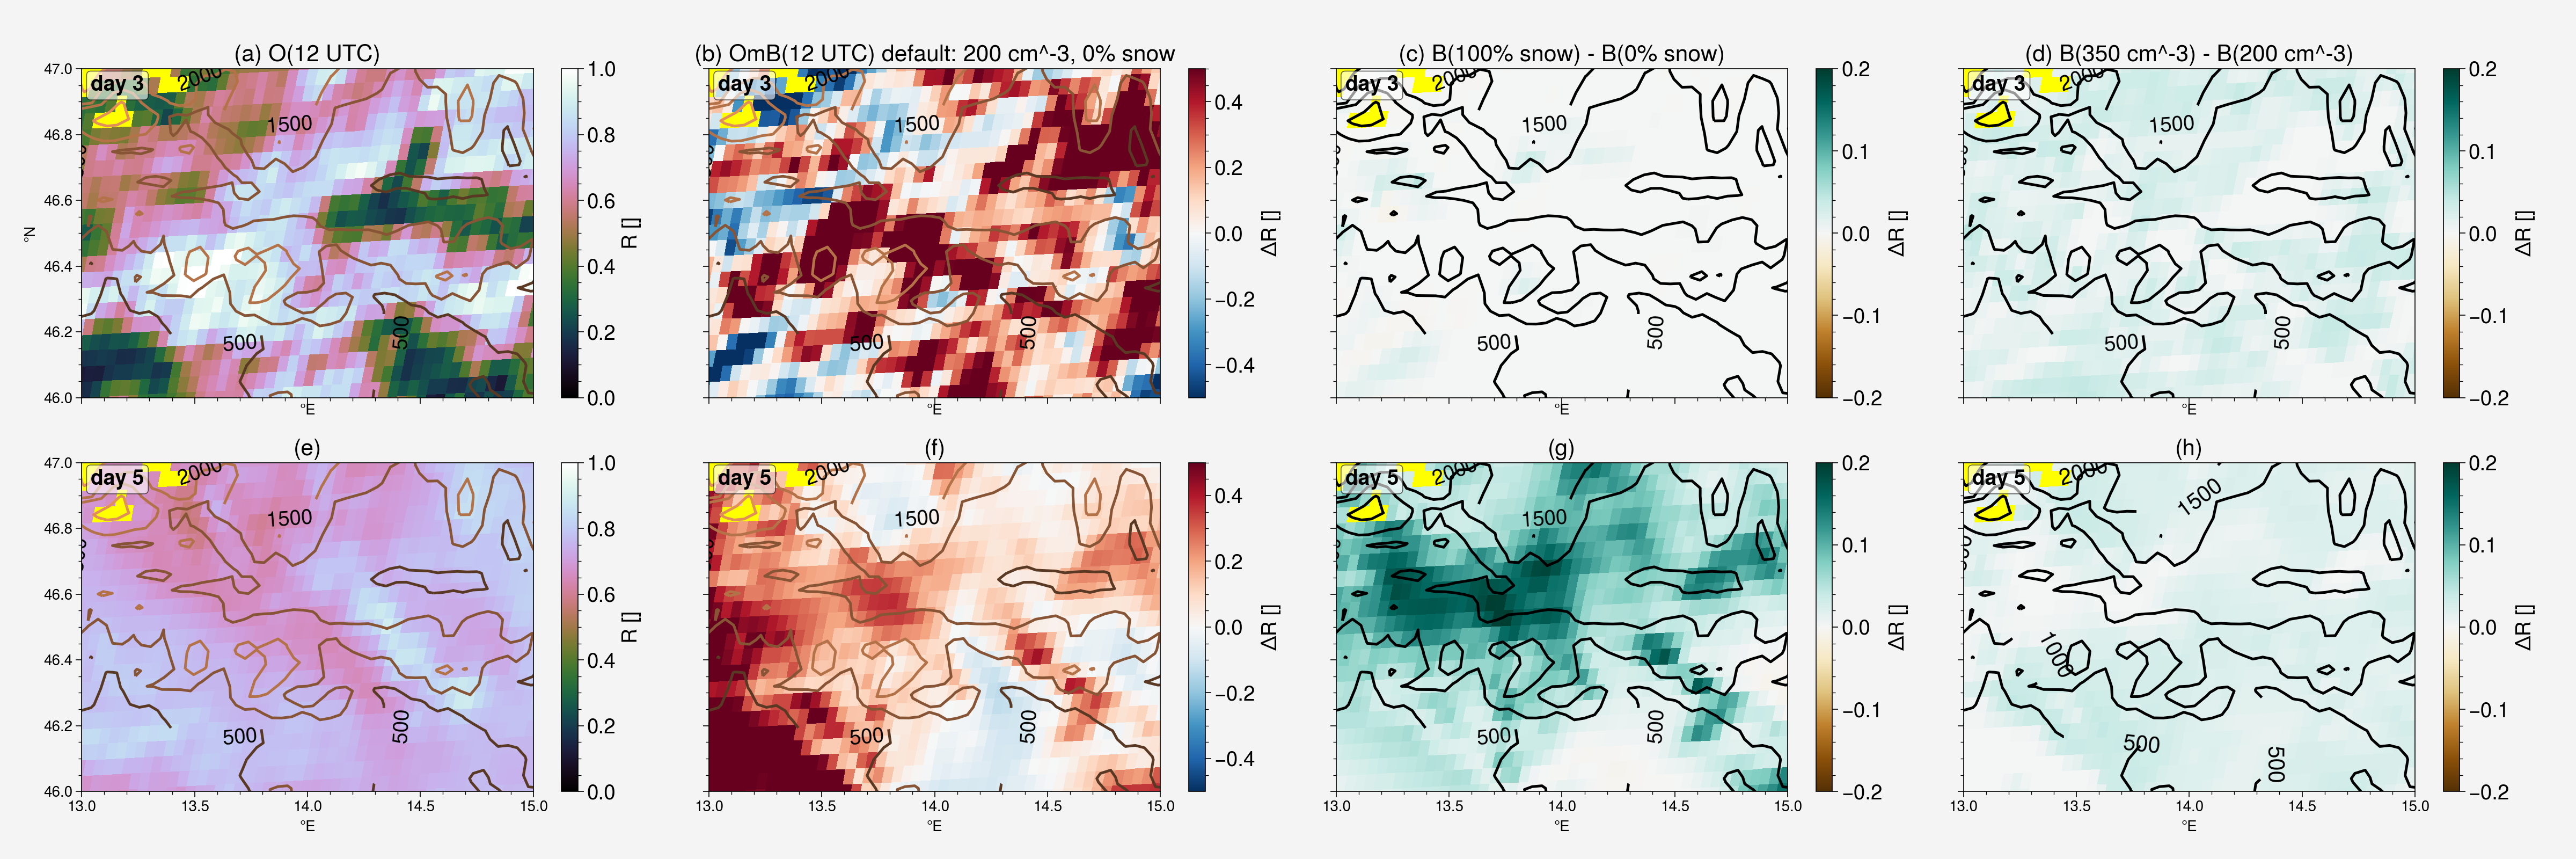

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

vmin, vmax = -0.2, 0.2
# --- create a 1×3 figure ---
fig, axees = plt.subplots(2, 4, figsize=(24, 8), sharex=True, sharey=True)
plt.rcParams.update({'font.size': 14})
axes = axees.flatten()

# common formatter for lon/lat
i = 0
for ax in axes:
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
    ax.set_xlim(13, 15)
    ax.set_ylim(46, 47)
    ax.set_xlabel("°E")
    if i > 3:
        ax.text(0.02, 0.98, f"day 5",
            transform=ax.transAxes,
            va='top', ha='left',
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))
    elif i < 4:
        ax.text(0.02, 0.98, f"day 3",
            transform=ax.transAxes,
            va='top', ha='left',
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))
    i = i + 1
axes[0].set_ylabel("°N")

# --- panel 1: O difference ---
pcm1 = axes[0].pcolormesh(x, y, p1,
                          vmin=0, vmax=1,
                          cmap='cubehelix', shading='auto')
cbar1 = fig.colorbar(pcm1, ax=axes[0], label="R []")
cont1 = axes[0].contour(x, y, z_terrain,
                       levels=5, cmap="copper", linewidths=1.8)
axes[0].clabel(cont1, inline=True, fontsize=14, colors='black', fmt='%10.0f')
axes[0].set_title("(a) O(12 UTC)")
axes[0].set_facecolor('yellow')

# --- panel 2: B difference ---
pcm2 = axes[1].pcolormesh(x, y, p2,
                          vmin=-0.5, vmax=0.5,
                          cmap='RdBu_r', shading='auto')
cbar2 = fig.colorbar(pcm2, ax=axes[1], label="ΔR []")
cont2 = axes[1].contour(x, y, z_terrain,
                       levels=5, cmap="copper",linewidths=1.8)
axes[1].clabel(cont2, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[1].set_title("(b) OmB(12 UTC) default: 200 cm^-3, 0% snow")
axes[1].set_facecolor('yellow')
# --- panel 3: terrain ---
pcm3 = axes[2].pcolormesh(x, y, p3,
                          vmin=vmin, vmax=vmax,
                          cmap='BrBG', shading='auto')
cbar3 = fig.colorbar(pcm3, ax=axes[2], label="ΔR []")
cont3 = axes[2].contour(x, y, z_terrain,
                       levels=5, colors="black", linewidths=1.8)
axes[2].clabel(cont3, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[2].set_title("(c) B(100% snow) - B(0% snow)")
axes[2].set_facecolor('yellow')
# --- panel 3: terrain ---
pcm4 = axes[3].pcolormesh(x, y, p4,
                          vmin=vmin, vmax=vmax,
                          cmap='BrBG', shading='auto')
cbar4 = fig.colorbar(pcm4, ax=axes[3], label="ΔR []")
cbar4 = axes[3].contour(x, y, z_terrain,
                       levels=5, colors="black", linewidths=1.8)
axes[3].clabel(cbar4, inline=True, fontsize=14, colors='black', fmt='%10.0f')
axes[3].set_title("(d) B(350 cm^-3) - B(200 cm^-3)")
axes[3].set_facecolor('yellow')

# --- panel 1: O difference ---
pcm5 = axes[4].pcolormesh(x, y, p5,
                          vmin=0, vmax=1,
                          cmap='cubehelix', shading='auto')
cbar1 = fig.colorbar(pcm5, ax=axes[4], label="R []")
cont1 = axes[4].contour(x, y, z_terrain,
                       levels=5, cmap="copper", linewidths=1.8)
axes[4].clabel(cont1, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[4].set_title("(e)")
axes[4].set_facecolor('yellow')
# --- panel 2: B difference ---
pcm6 = axes[5].pcolormesh(x, y, p6,
                          vmin=-0.5, vmax=0.5,
                          cmap='RdBu_r', shading='auto')
cbar2 = fig.colorbar(pcm6, ax=axes[5], label="ΔR []")
cont2 = axes[5].contour(x, y, z_terrain,
                       levels=5, cmap="copper",linewidths=1.8)
axes[5].clabel(cont2, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[5].set_title("(f)")
axes[5].set_facecolor('yellow')
# --- panel 3: terrain ---
pcm7 = axes[6].pcolormesh(x, y, p7,
                          vmin=vmin, vmax=vmax,
                          cmap='BrBG', shading='auto')
cbar3 = fig.colorbar(pcm7, ax=axes[6], label="ΔR []")
cont3 = axes[6].contour(x, y, z_terrain,
                       levels=5, colors="black", linewidths=1.8)
axes[6].clabel(cont3, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[6].set_title("(g)")
axes[6].set_facecolor('yellow')
# --- panel 3: terrain ---
pcm8 = axes[7].pcolormesh(x, y, p8,
                          vmin=vmin, vmax=vmax,
                          cmap='BrBG', shading='auto')
cbar8 = fig.colorbar(pcm8, ax=axes[7], label="ΔR []")
cbar8 = axes[7].contour(x, y, z_terrain,
                       levels=5, colors="black", linewidths=1.8)
axes[7].clabel(cbar8, inline=True, fontsize=15, colors='black', fmt='%10.0f')

axes[7].set_title("(h)")
axes[7].set_facecolor('yellow')

# --- layout & save ---
plt.tight_layout()
plt.subplots_adjust(top=0.92)
# plt.savefig("/home/km4c/to_ucloud/CCN&snow_effects.png", dpi=1200)
plt.show()